In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


/tmp/ipykernel_3667647/1242282700.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_3667647/1242282700.py:105: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


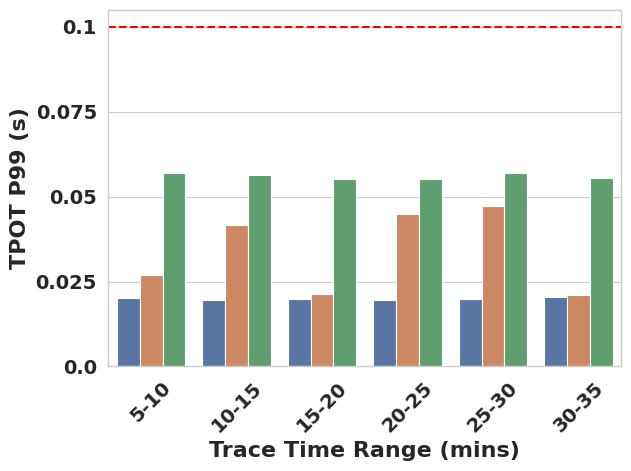

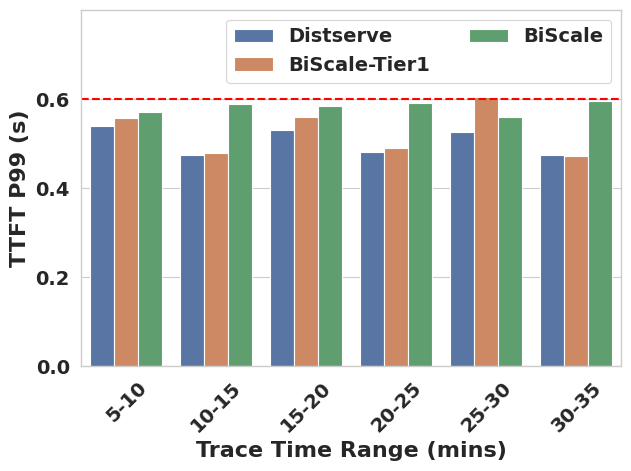

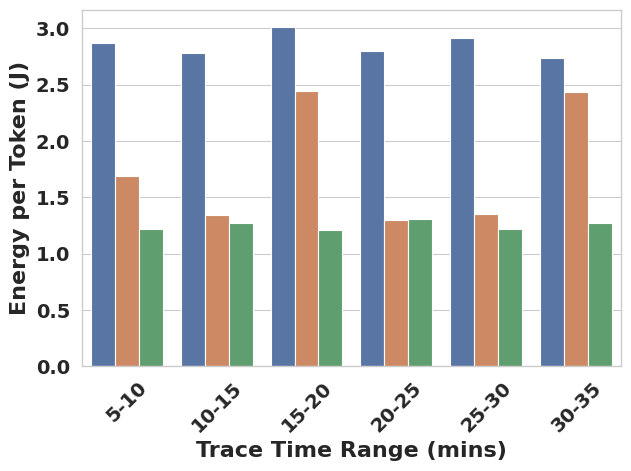

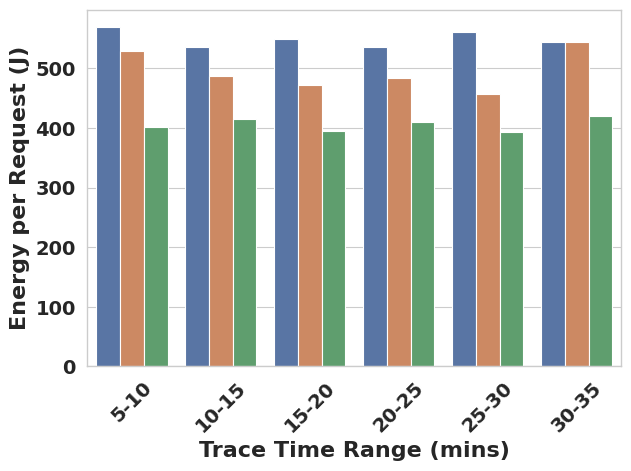

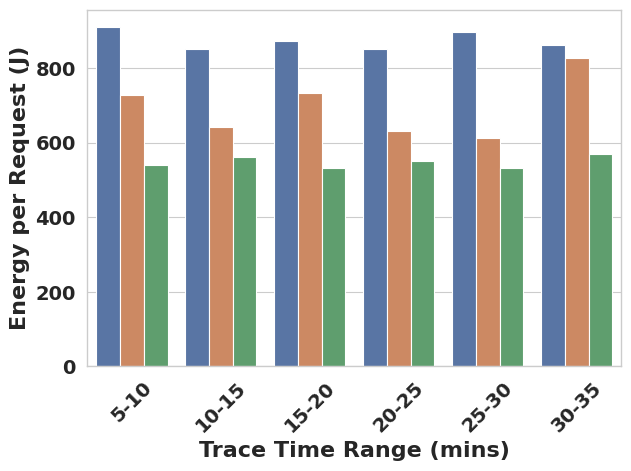

In [2]:
path = "/export5/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/azure_conv/profiler_logs_0/metrics.csv"
df_results_disag = pd.read_csv(path)

path = '/export5/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/azure_conv_retry_540/profiler_logs_0/metrics.csv'
df_results_dvfs = pd.read_csv(path)

# path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/profiler_logs_Feb25_chunk_fix_freq_0/real/metrics.csv'
# df_results_collocated_fix_freq = pd.read_csv(path)

# path = '/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/67_percent_char_balance_dvfs_redo_together_ai/profiler_logs_0/metrics.csv'
# df_results_together_ai_disag_dvfs = pd.read_csv(path)

df_results = pd.concat([df_results_disag, df_results_dvfs])

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_MARCH31_AZURE_CONV_P67_6_node0': 'Distserve 85',
    'DISTSERVE_MARCH31_AZURE_CONV_P67_5_node0': 'Distserve 70',
    'DISTSERVE_MARCH31_AZURE_CONV_P67_4_node0': 'Distserve 55',
    'DISTSERVE_MARCH31_AZURE_CONV_P67_3_node0': 'Distserve 40',
    'DISTSERVE_MARCH31_AZURE_CONV_P67_2_node0': 'Distserve 25',
    'DISTSERVE_MARCH31_AZURE_CONV_P67_1_node0': 'Distserve 10',
    'OURS_MARCH31_AZURE_CONV_P67_6_node0': 'BiScale-Tier1 85',
    'OURS_MARCH31_AZURE_CONV_P67_5_node0': 'BiScale-Tier1 70',
    'OURS_MARCH31_AZURE_CONV_P67_4_node0': 'BiScale-Tier1 55',
    'OURS_MARCH31_AZURE_CONV_P67_3_node0': 'BiScale-Tier1 40',
    'OURS_MARCH31_AZURE_CONV_P67_2_node0': 'BiScale-Tier1 25',
    'OURS_MARCH31_AZURE_CONV_P67_1_node0': 'BiScale-Tier1 10',
    'OURS_APR1_AZURE_CONV_P67_6_DVFS_node0': 'BiScale 10',
    'OURS_APR1_AZURE_CONV_P67_5_DVFS_node0': 'BiScale 25',
    'OURS_APR1_AZURE_CONV_P67_4_DVFS_node0': 'BiScale 40',
    'OURS_APR1_AZURE_CONV_P67_3_DVFS_node0': 'BiScale 55',
    'OURS_APR1_AZURE_CONV_P67_2_DVFS_node0': 'BiScale 70',
    'OURS_APR1_AZURE_CONV_P67_1_DVFS_node0': 'BiScale 85',
}


# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)
df_results = df_results[df_results['expr_dir'].isin(rename_mapping.values())]
df_results = df_results[~df_results['expr_dir'].str.contains('OURS_R5_JAN3_OLD_P90_.*_DVFS', regex=True)]

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'BiScale-Tier1', 'BiScale'], ordered=True)
# df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'BiScale-Tier1', 'BiScale', 'Collocated-Tier1', 'Collocated'], ordered=True)

df_results = df_results.sort_values(['rps', 'name'])

####################### TPOT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TPOT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.105)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.025, 0.05, 0.075, 0.1])
ax.set_yticklabels(['0.0', '0.025', '0.05', '0.075', '0.1'], fontsize=14, fontweight='bold')
ax.legend_.remove()

plt.tight_layout()
plt.savefig("figs/real_67p_trace_tpot_azure.pdf", format="pdf")

######################## TTFT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TTFT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.8)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6'], fontsize=14, fontweight='bold')
ax.legend(title="", ncol=2, prop={"size": 14, "weight": "bold"})

plt.tight_layout()
plt.savefig("figs/real_67p_trace_ttft_azure.pdf", format="pdf")

############################ energy per token - decode #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="decode_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Token (J)', fontsize=16, fontweight='bold')

ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend(title="", ncol=2, prop={"size": 14, "weight": "bold"})
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/real_67p_trace_energy_per_token_decode_azure.pdf", format="pdf")

############################ energy per request - prefill #######################
df_results_dis = df_results[df_results["name"].isin(["Distserve", "BiScale-Tier1", "BiScale"])].copy()
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="prefill_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Request (J)', fontsize=16, fontweight='bold')

ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/real_67p_trace_energy_per_request_prefill_azure.pdf", format="pdf")

############################ energy per request - total #######################

df_results['energy_per_req'] = df_results['energy_j'] / df_results['num_requests']
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_req", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Request (J)', fontsize=16, fontweight='bold')

ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/real_67p_trace_energy_per_request_total_azure.pdf", format="pdf")

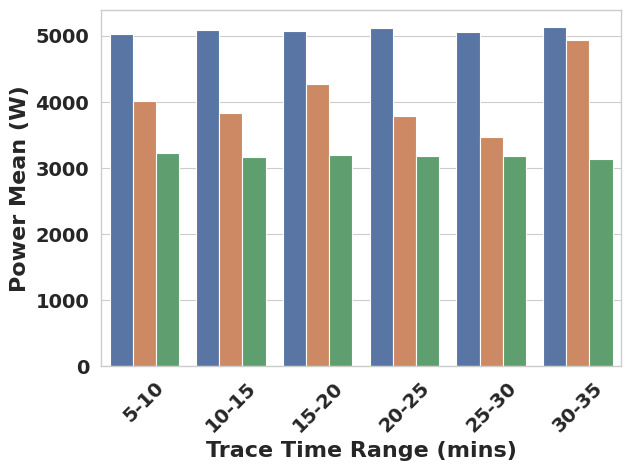

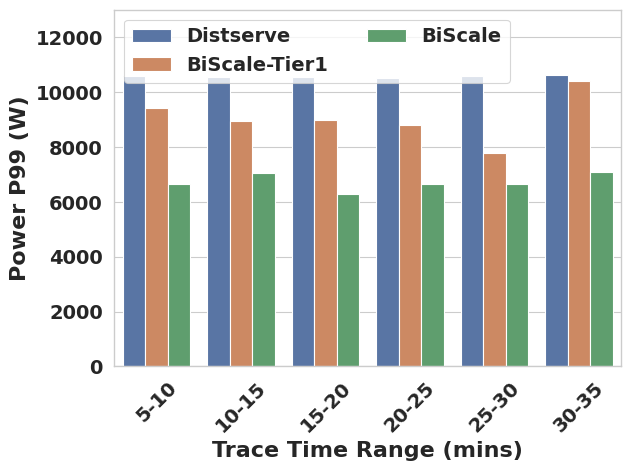

In [8]:
############################ power mean #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps",
    y="power_mean",
    hue="name",
    data=df_results,
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Power Mean (W)', fontsize=16, fontweight='bold')

ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/real_67p_trace_power_mean_azure.pdf", format="pdf")

############################ power p99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps",
    y="power_p99",
    hue="name",
    data=df_results,
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Power P99 (W)', fontsize=16, fontweight='bold')

ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend(title="", ncol=2, prop={"size": 14, "weight": "bold"})
plt.ylim(0, 13000)
plt.tight_layout()
plt.savefig("figs/real_67p_trace_power_p99_azure.pdf", format="pdf")


In [4]:
# Normalize energy with Distserve energy for both prefill and decode
df_results['energy_norm_prefi_D'] = df_results.apply(
    lambda row: (1 - row['prefill_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['prefill_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_deco_D'] = df_results.apply(
    lambda row: (1 - row['decode_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['decode_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_prefi_M'] = df_results.apply(
    lambda row: (1 - row['prefill_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'BiScale-Tier1')
    ]['prefill_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_deco_M'] = df_results.apply(
    lambda row: (1 - row['decode_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'BiScale-Tier1')
    ]['decode_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_D'] = df_results.apply(
    lambda row: (1 - row['energy_per_req'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['energy_per_req'].values[0]) * 100,
    axis=1
)

df_results[['expr_dir', 'energy_per_token', 'energy_norm_prefi_D', 'energy_norm_deco_D', 'energy_norm_prefi_M', 'energy_norm_deco_M', 'energy_norm_D']].sort_values('expr_dir', ascending=False)

,expr_dir,energy_per_token,energy_norm_prefi_D,energy_norm_deco_D,energy_norm_prefi_M,energy_norm_deco_M,energy_norm_D
29,Distserve 85,7.360999,0.000000,0.000000,0.091675,-12.239238,0.000000
24,Distserve 70,7.696699,0.000000,0.000000,-22.503256,-115.800069,0.000000
19,Distserve 55,7.458772,0.000000,0.000000,-10.838967,-115.793420,0.000000
14,Distserve 40,8.052919,0.000000,0.000000,-16.572712,-23.508265,0.000000
9,Distserve 25,7.405749,0.000000,0.000000,-9.785894,-106.709704,0.000000
4,Distserve 10,7.602478,0.000000,0.000000,-7.831892,-69.843317,0.000000
89,BiScale-Tier1 85,7.070578,-0.091759,10.904598,0.000000,0.000000,3.964329
79,BiScale-Tier1 70,5.242174,18.369517,53.660812,0.000000,0.000000,31.491513
69,BiScale-Tier1 55,5.474546,9.779022,53.659384,0.000000,0.000000,25.944550
59,BiScale-Tier1 40,6.761513,14.216631,19.033759,0.000000,0.000000,15.982652
